In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 60)

BASE_PATH = '/kaggle/input/competitions/child-mind-institute-problematic-internet-use'
TRAIN_PATH = f'{BASE_PATH}/train.csv'
TEST_PATH  = f'{BASE_PATH}/test.csv'
DICT_PATH  = f'{BASE_PATH}/data_dictionary.csv'
SAMPLE_PATH = f'{BASE_PATH}/sample_submission.csv'
SERIES_TRAIN_PATH = f'{BASE_PATH}/series_train.parquet'
SERIES_TEST_PATH  = f'{BASE_PATH}/series_test.parquet'

print("Files available:")
for f in os.listdir(BASE_PATH):
    print(f" {f}")


Files available:
 sample_submission.csv
 data_dictionary.csv
 series_test.parquet
 series_train.parquet
 train.csv
 test.csv


cell 2: Load tabular data

In [9]:
train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)
data_dict = pd.read_csv(DICT_PATH)
sample_sub = pd.read_csv(SAMPLE_PATH)

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")
print(f"\nTrain columns ({len(train.columns)}):")
print(list(train.columns))

Train shape: (3960, 82)
Test shape:  (20, 59)

Train columns (82):
['id', 'Basic_Demos-Enroll_Season', 'Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-Season', 'CGAS-CGAS_Score', 'Physical-Season', 'Physical-BMI', 'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference', 'Physical-Diastolic_BP', 'Physical-HeartRate', 'Physical-Systolic_BP', 'Fitness_Endurance-Season', 'Fitness_Endurance-Max_Stage', 'Fitness_Endurance-Time_Mins', 'Fitness_Endurance-Time_Sec', 'FGC-Season', 'FGC-FGC_CU', 'FGC-FGC_CU_Zone', 'FGC-FGC_GSND', 'FGC-FGC_GSND_Zone', 'FGC-FGC_GSD', 'FGC-FGC_GSD_Zone', 'FGC-FGC_PU', 'FGC-FGC_PU_Zone', 'FGC-FGC_SRL', 'FGC-FGC_SRL_Zone', 'FGC-FGC_SRR', 'FGC-FGC_SRR_Zone', 'FGC-FGC_TL', 'FGC-FGC_TL_Zone', 'BIA-Season', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMI', 'BIA-BIA_BMR', 'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_FFM', 'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num', 'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM', 'BIA-BIA_TBW'

cell 3: inspect target variable

sii
0.0    1594
1.0     730
2.0     378
3.0      34
NaN    1224
Name: count, dtype: int64

Missing sii: 1224 / 3960 rows
  → 30.9% unlabeled (will use for semi-supervised later)


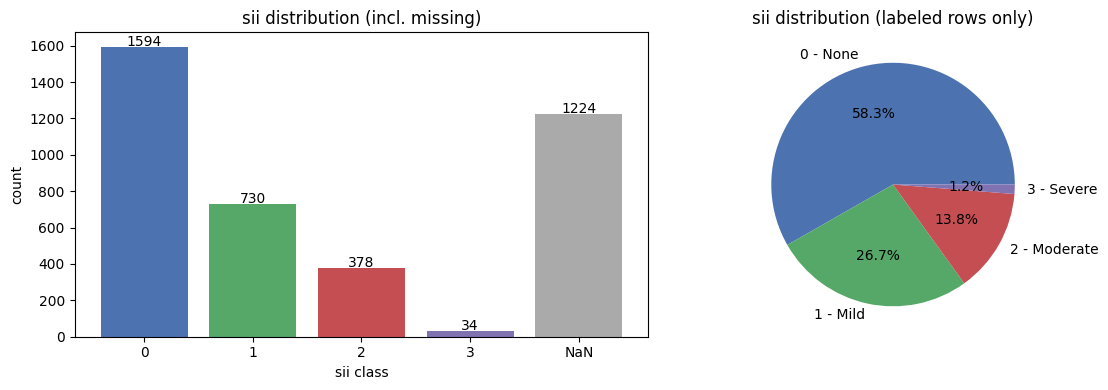

In [ ]:
print(train['sii'].value_counts(dropna=False).sort_index())
print(f"\nMissing sii: {train['sii'].isna().sum()} / {len(train)} rows")
print(f"  → {train['sii'].isna().mean()*100:.1f}% unlabeled (will use for semi-supervised later)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = train['sii'].value_counts(dropna=False).sort_index()
labels = [str(int(x)) if pd.notna(x) else 'NaN' for x in counts.index]
axes[0].bar(labels, counts.values, color=['#4C72B0','#55A868','#C44E52','#8172B2','#AAAAAA'])
axes[0].set_title('sii distribution (incl. missing)')
axes[0].set_xlabel('sii class')
axes[0].set_ylabel('count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=10)

labeled = train.dropna(subset=['sii'])
axes[1].pie(
    labeled['sii'].value_counts().sort_index(),
    labels=['0 - None','1 - Mild','2 - Moderate','3 - Severe'],
    autopct='%1.1f%%',
    colors=['#4C72B0','#55A868','#C44E52','#8172B2']
)
axes[1].set_title('sii distribution (labeled rows only)')

plt.tight_layout()
plt.show()

cell 4: missing value overview


=== TRAIN: 78 columns have missing values ===
                                        missing_count  missing_pct
PAQ_A-Season                                     3485         88.0
PAQ_A-PAQ_A_Total                                3485         88.0
Fitness_Endurance-Time_Sec                       3220         81.3
Fitness_Endurance-Time_Mins                      3220         81.3
Fitness_Endurance-Max_Stage                      3217         81.2
Physical-Waist_Circumference                     3062         77.3
FGC-FGC_GSND_Zone                                2898         73.2
FGC-FGC_GSD_Zone                                 2897         73.2
FGC-FGC_GSD                                      2886         72.9
FGC-FGC_GSND                                     2886         72.9
Fitness_Endurance-Season                         2652         67.0
PAQ_C-PAQ_C_Total                                2239         56.5
PAQ_C-Season                                     2239         56.5
BIA-BIA_FFMI   

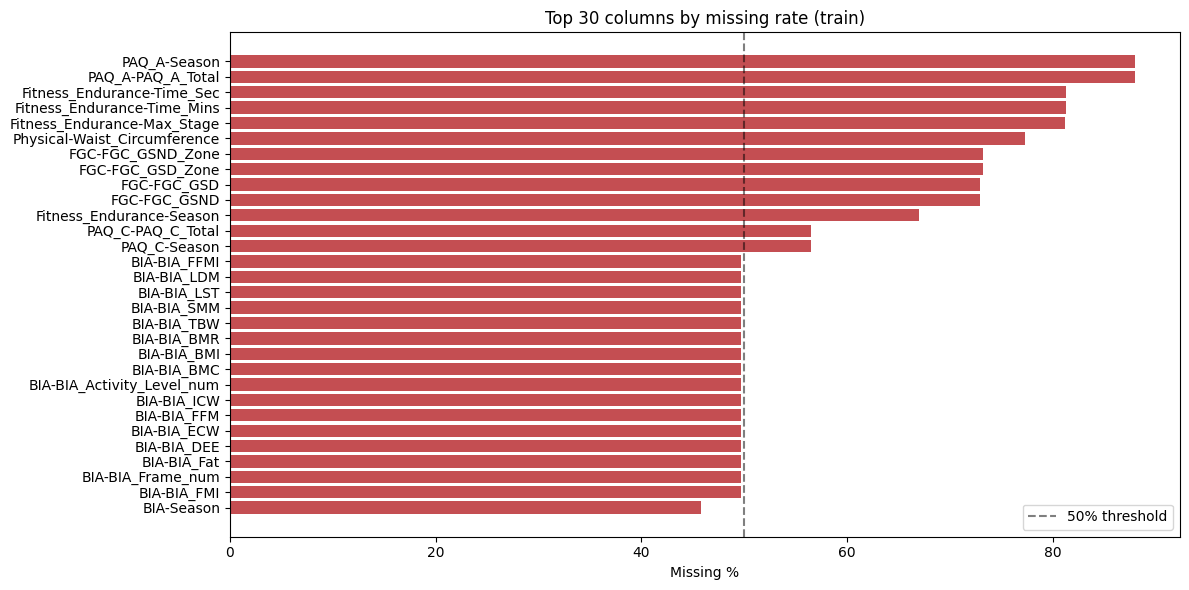

In [11]:
def missing_report(df, name):
    miss = df.isna().sum()
    miss = miss[miss > 0].sort_values(ascending=False)
    pct  = (miss / len(df) * 100).round(1)
    report = pd.DataFrame({'missing_count': miss, 'missing_pct': pct})
    print(f"\n=== {name}: {len(miss)} columns have missing values ===")
    print(report.to_string())
    return report

train_missing = missing_report(train, "TRAIN")
test_missing  = missing_report(test,  "TEST")


top30 = train_missing.head(30)
plt.figure(figsize=(12, 6))
plt.barh(top30.index[::-1], top30['missing_pct'][::-1], color='#C44E52')
plt.axvline(50, color='black', linestyle='--', alpha=0.5, label='50% threshold')
plt.xlabel('Missing %')
plt.title('Top 30 columns by missing rate (train)')
plt.legend()
plt.tight_layout()
plt.show()

cell 5: instrument groups exploration

In [ ]:
instrument_groups = {
    'Demographics':     [c for c in train.columns if c.startswith('Basic_Demos')],
    'Internet Use':     [c for c in train.columns if c.startswith('PreInt_EduHx')],
    'Physical':         [c for c in train.columns if c.startswith('Physical')],
    'FitnessGram':      [c for c in train.columns if c.startswith('Fitness')],
    'BIA':              [c for c in train.columns if c.startswith('BIA')],
    'PAQ':              [c for c in train.columns if c.startswith('PAQ')],
    'SDS':              [c for c in train.columns if c.startswith('SDS')],
    'CGAS':             [c for c in train.columns if c.startswith('CGAS')],
    'PCIAT':            [c for c in train.columns if c.startswith('PCIAT')],
}

print("=== Instrument groups ===")
for group, cols in instrument_groups.items():
    n_miss = train[cols].isna().all(axis=1).sum() if cols else 0
    print(f"  {group:15s}: {len(cols):3d} cols  |  rows with ALL missing: {n_miss}")

pciat_cols = instrument_groups['PCIAT']
print(f"\n PCIAT columns (TARGET LEAKAGE — must drop before modeling):")
print(pciat_cols)

=== Instrument groups ===
  Demographics   :   3 cols  |  rows with ALL missing: 0
  Internet Use   :   2 cols  |  rows with ALL missing: 420
  Physical       :   8 cols  |  rows with ALL missing: 650
  FitnessGram    :   4 cols  |  rows with ALL missing: 2652
  BIA            :  17 cols  |  rows with ALL missing: 1815
  PAQ            :   4 cols  |  rows with ALL missing: 1765
  SDS            :   3 cols  |  rows with ALL missing: 1342
  CGAS           :   2 cols  |  rows with ALL missing: 1405
  PCIAT          :  22 cols  |  rows with ALL missing: 1224

 PCIAT columns (TARGET LEAKAGE — must drop before modeling):
['PCIAT-Season', 'PCIAT-PCIAT_01', 'PCIAT-PCIAT_02', 'PCIAT-PCIAT_03', 'PCIAT-PCIAT_04', 'PCIAT-PCIAT_05', 'PCIAT-PCIAT_06', 'PCIAT-PCIAT_07', 'PCIAT-PCIAT_08', 'PCIAT-PCIAT_09', 'PCIAT-PCIAT_10', 'PCIAT-PCIAT_11', 'PCIAT-PCIAT_12', 'PCIAT-PCIAT_13', 'PCIAT-PCIAT_14', 'PCIAT-PCIAT_15', 'PCIAT-PCIAT_16', 'PCIAT-PCIAT_17', 'PCIAT-PCIAT_18', 'PCIAT-PCIAT_19', 'PCIAT-PCIAT_20', 

Cell 6 — Numeric Feature Distributions by sii

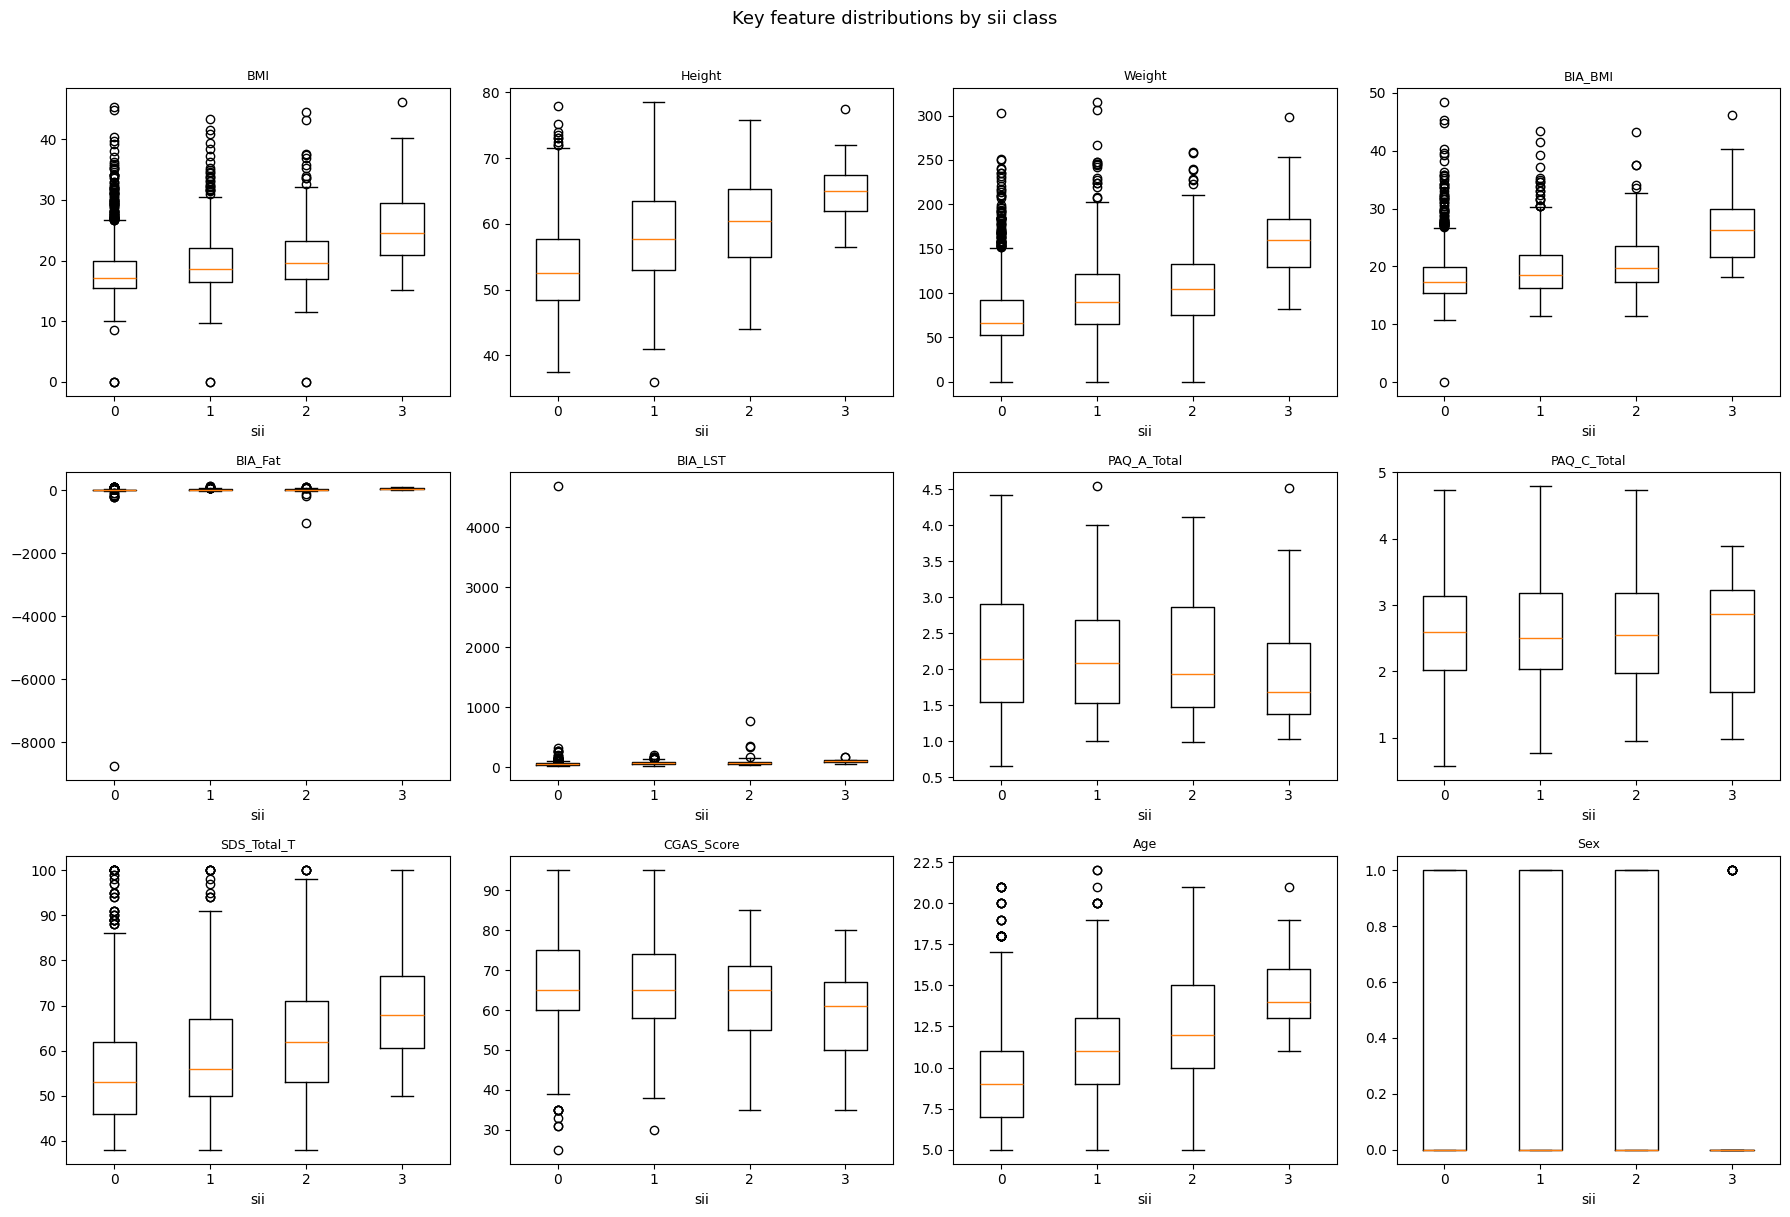

In [ ]:
labeled = train.dropna(subset=['sii']).copy()

key_features = [
    'Physical-BMI', 'Physical-Height', 'Physical-Weight',
    'BIA-BIA_BMI', 'BIA-BIA_Fat', 'BIA-BIA_LST',
    'PAQ_A-PAQ_A_Total', 'PAQ_C-PAQ_C_Total',
    'SDS-SDS_Total_T', 'CGAS-CGAS_Score',
    'Basic_Demos-Age', 'Basic_Demos-Sex'
]
key_features = [f for f in key_features if f in labeled.columns]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(key_features):
    if i >= len(axes): break
    data_by_class = [labeled[labeled['sii'] == c][col].dropna() for c in [0,1,2,3]]
    axes[i].boxplot(data_by_class, labels=['0','1','2','3'])
    axes[i].set_title(col.split('-')[-1], fontsize=9)
    axes[i].set_xlabel('sii')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Key feature distributions by sii class', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Cell 7 — Correlation with Target

Top 20 features correlated with sii:
Physical-Height                           0.374
Basic_Demos-Age                           0.366
PreInt_EduHx-computerinternet_hoursday    0.337
Physical-Weight                           0.326
Physical-Waist_Circumference              0.273
FGC-FGC_CU                                0.247
SDS-SDS_Total_T                           0.233
SDS-SDS_Total_Raw                         0.230
BIA-BIA_BMI                               0.228
Physical-BMI                              0.221
FGC-FGC_PU                                0.177
BIA-BIA_Frame_num                         0.166
FGC-FGC_GSD                               0.163
FGC-FGC_GSND                              0.149
Physical-Systolic_BP                      0.135
FGC-FGC_SRL_Zone                          0.112
FGC-FGC_TL                                0.108
BIA-BIA_FFMI                              0.103
Basic_Demos-Sex                           0.100
CGAS-CGAS_Score                           0.085


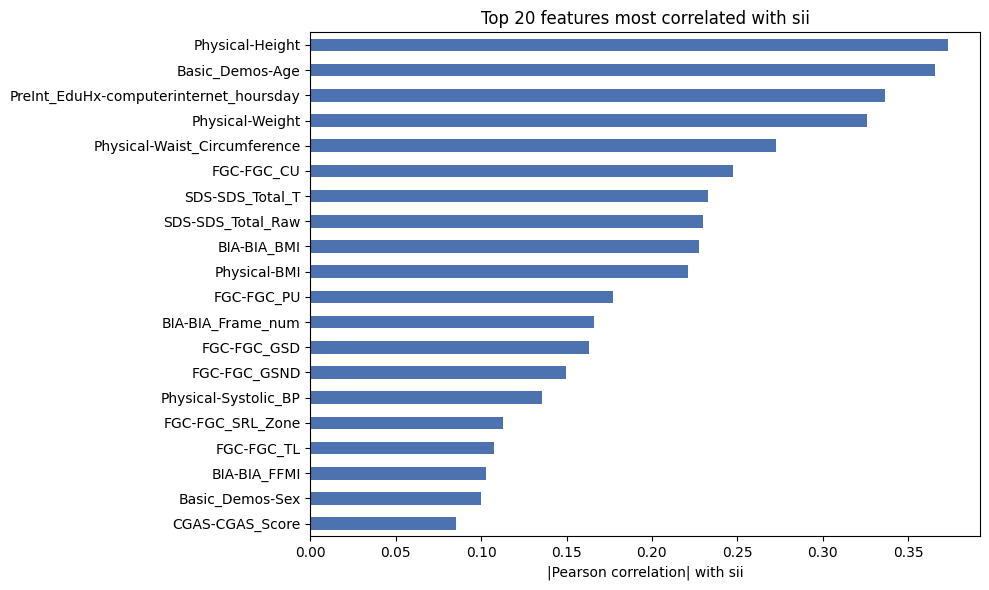

In [ ]:
labeled_num = labeled.select_dtypes(include=[np.number]).copy()

drop_cols = [c for c in labeled_num.columns if 'PCIAT' in c] + ['sii']
labeled_num = labeled_num.drop(columns=drop_cols, errors='ignore')

correlations = labeled_num.corrwith(labeled['sii']).dropna().abs().sort_values(ascending=False)

print("Top 20 features correlated with sii:")
print(correlations.head(20).round(3).to_string())

plt.figure(figsize=(10, 6))
correlations.head(20).sort_values().plot(kind='barh', color='#4C72B0')
plt.xlabel('|Pearson correlation| with sii')
plt.title('Top 20 features most correlated with sii')
plt.tight_layout()
plt.show()

Cell 8 — Check Actigraphy Coverage

In [ ]:
import pyarrow.parquet as pq

acti_train_ids = set()
series_train_dir = SERIES_TRAIN_PATH

for entry in os.scandir(series_train_dir):
    if entry.is_dir() and entry.name.startswith('id='):
        acti_train_ids.add(entry.name.split('=')[1])

acti_test_ids = set()
for entry in os.scandir(SERIES_TEST_PATH):
    if entry.is_dir() and entry.name.startswith('id='):
        acti_test_ids.add(entry.name.split('=')[1])

print(f"Participants with actigraphy in TRAIN: {len(acti_train_ids)} / {len(train)}")
print(f"Participants with actigraphy in TEST:  {len(acti_test_ids)} / {len(test)}")

train['has_actigraphy'] = train['id'].isin(acti_train_ids).astype(int)
test['has_actigraphy']  = test['id'].isin(acti_test_ids).astype(int)

print("\nTrain sii availability vs actigraphy:")
print(pd.crosstab(train['has_actigraphy'], train['sii'].isna().map({True:'sii_missing', False:'sii_present'})))

Participants with actigraphy in TRAIN: 996 / 3960
Participants with actigraphy in TEST:  2 / 20

Train sii availability vs actigraphy:
sii             sii_missing  sii_present
has_actigraphy                          
0                      1224         1740
1                         0          996


Cell 9 — Preprocessing: Drop Leakage & Low-Coverage Columns

In [ ]:
pciat_cols = [c for c in train.columns if 'PCIAT' in c]
print(f"Dropping {len(pciat_cols)} PCIAT columns (leakage): {pciat_cols}")

train_clean = train.drop(columns=pciat_cols)
test_clean  = test.drop(columns=pciat_cols, errors='ignore')

threshold = 0.70
miss_rate = train_clean.isna().mean()
high_miss_cols = miss_rate[miss_rate > threshold].index.tolist()
print(f"\nDropping {len(high_miss_cols)} columns with >{threshold*100:.0f}% missing:")
print(high_miss_cols)

train_clean = train_clean.drop(columns=high_miss_cols)
test_clean  = test_clean.drop(columns=high_miss_cols, errors='ignore')

print(f"\nShape after dropping: train {train_clean.shape} | test {test_clean.shape}")

Dropping 22 PCIAT columns (leakage): ['PCIAT-Season', 'PCIAT-PCIAT_01', 'PCIAT-PCIAT_02', 'PCIAT-PCIAT_03', 'PCIAT-PCIAT_04', 'PCIAT-PCIAT_05', 'PCIAT-PCIAT_06', 'PCIAT-PCIAT_07', 'PCIAT-PCIAT_08', 'PCIAT-PCIAT_09', 'PCIAT-PCIAT_10', 'PCIAT-PCIAT_11', 'PCIAT-PCIAT_12', 'PCIAT-PCIAT_13', 'PCIAT-PCIAT_14', 'PCIAT-PCIAT_15', 'PCIAT-PCIAT_16', 'PCIAT-PCIAT_17', 'PCIAT-PCIAT_18', 'PCIAT-PCIAT_19', 'PCIAT-PCIAT_20', 'PCIAT-PCIAT_Total']

Dropping 10 columns with >70% missing:
['Physical-Waist_Circumference', 'Fitness_Endurance-Max_Stage', 'Fitness_Endurance-Time_Mins', 'Fitness_Endurance-Time_Sec', 'FGC-FGC_GSND', 'FGC-FGC_GSND_Zone', 'FGC-FGC_GSD', 'FGC-FGC_GSD_Zone', 'PAQ_A-Season', 'PAQ_A-PAQ_A_Total']

Shape after dropping: train (3960, 51) | test (20, 50)


Cell 10 — Preprocessing: Encode Categoricals & Impute

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

cat_cols = train_clean.select_dtypes(include=['object']).columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['id']]
num_cols = train_clean.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ['sii']]

print(f"Categorical columns: {cat_cols}")
print(f"Numeric columns: {len(num_cols)}")

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([train_clean[col], test_clean[col]], axis=0).fillna('__missing__')
    le.fit(combined)
    train_clean[col] = le.transform(train_clean[col].fillna('__missing__'))
    test_clean[col]  = le.transform(test_clean[col].fillna('__missing__'))
    le_dict[col] = le
    print(f"  Encoded '{col}': {list(le.classes_)}")

imputer = SimpleImputer(strategy='median')
train_clean[num_cols] = imputer.fit_transform(train_clean[num_cols])
test_clean[num_cols]  = imputer.transform(test_clean[num_cols])

print(f"\nMissing after imputation — train: {train_clean[num_cols].isna().sum().sum()}")
print(f"Missing after imputation — test:  {test_clean[num_cols].isna().sum().sum()}")

Categorical columns: ['Basic_Demos-Enroll_Season', 'CGAS-Season', 'Physical-Season', 'Fitness_Endurance-Season', 'FGC-Season', 'BIA-Season', 'PAQ_C-Season', 'SDS-Season', 'PreInt_EduHx-Season']
Numeric columns: 40
  Encoded 'Basic_Demos-Enroll_Season': ['Fall', 'Spring', 'Summer', 'Winter']
  Encoded 'CGAS-Season': ['Fall', 'Spring', 'Summer', 'Winter', '__missing__']
  Encoded 'Physical-Season': ['Fall', 'Spring', 'Summer', 'Winter', '__missing__']
  Encoded 'Fitness_Endurance-Season': ['Fall', 'Spring', 'Summer', 'Winter', '__missing__']
  Encoded 'FGC-Season': ['Fall', 'Spring', 'Summer', 'Winter', '__missing__']
  Encoded 'BIA-Season': ['Fall', 'Spring', 'Summer', 'Winter', '__missing__']
  Encoded 'PAQ_C-Season': ['Fall', 'Spring', 'Summer', 'Winter', '__missing__']
  Encoded 'SDS-Season': ['Fall', 'Spring', 'Summer', 'Winter', '__missing__']
  Encoded 'PreInt_EduHx-Season': ['Fall', 'Spring', 'Summer', 'Winter', '__missing__']

Missing after imputation — train: 0
Missing after im

Cell 11 — Feature Engineering

In [ ]:
def add_features(df):
    df = df.copy()

    if 'Physical-Height' in df.columns and 'Physical-Weight' in df.columns:
        h = df['Physical-Height'] / 100
        w = df['Physical-Weight']
        df['calc_BMI'] = w / (h ** 2)

    if 'Basic_Demos-Age' in df.columns:
        df['age_group'] = pd.cut(
            df['Basic_Demos-Age'],
            bins=[0, 8, 12, 16, 25],
            labels=[0, 1, 2, 3]
        ).astype(float)

    paq_cols = [c for c in df.columns if 'PAQ' in c and 'Total' in c]
    if paq_cols:
        df['paq_combined'] = df[paq_cols].mean(axis=1)

    sds_cols = [c for c in df.columns if c.startswith('SDS')]
    if len(sds_cols) > 1:
        df['sds_mean'] = df[sds_cols].mean(axis=1)

    return df

train_clean = add_features(train_clean)
test_clean  = add_features(test_clean)

new_features = ['calc_BMI', 'age_group', 'paq_combined', 'sds_mean']
existing_new = [f for f in new_features if f in train_clean.columns]
print("New features added:", existing_new)
print(train_clean[existing_new].describe().round(2))

New features added: ['calc_BMI', 'age_group', 'paq_combined', 'sds_mean']
       calc_BMI  age_group  paq_combined  sds_mean
count   3960.00    3960.00       3960.00   3960.00
mean     266.62       0.98          2.56     33.18
std       71.41       0.91          0.52      6.40
min        0.00       0.00          0.58     18.67
25%      232.25       0.00          2.54     29.67
50%      254.55       1.00          2.54     32.67
75%      285.08       2.00          2.54     34.33
max      841.14       3.00          4.79     66.33


Cell 12 — Final Check & Save Preprocessed Data

In [ ]:
labeled_mask   = train_clean['sii'].notna()
train_labeled   = train_clean[labeled_mask].copy()
train_unlabeled = train_clean[~labeled_mask].copy()

drop_from_X = ['id', 'sii', 'has_actigraphy']
feature_cols = [c for c in train_labeled.columns if c not in drop_from_X]

X_train = train_labeled[feature_cols].reset_index(drop=True)
y_train = train_labeled['sii'].astype(int).reset_index(drop=True)
X_test  = test_clean[feature_cols].reset_index(drop=True)

print("=== Ready for modeling ===")
print(f"X_train shape:      {X_train.shape}")
print(f"y_train shape:      {y_train.shape}")
print(f"X_test shape:       {X_test.shape}")
print(f"Unlabeled rows:     {len(train_unlabeled)}")
print(f"\nClass distribution in y_train:")
print(y_train.value_counts().sort_index())

train_labeled.to_csv('train_preprocessed.csv', index=False)
test_clean.to_csv('test_preprocessed.csv', index=False)
print("\nSaved: train_preprocessed.csv, test_preprocessed.csv")

=== Ready for modeling ===
X_train shape:      (2736, 52)
y_train shape:      (2736,)
X_test shape:       (20, 52)
Unlabeled rows:     1224

Class distribution in y_train:
sii
0    1594
1     730
2     378
3      34
Name: count, dtype: int64

Saved: train_preprocessed.csv, test_preprocessed.csv


**STEP 3**